In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset (use your file path)
df = pd.read_csv("../data/bank.csv", sep=';')

# Show first 5 rows
df.head()

In [ ]:
# Dataset shape (rows, columns)
print("Shape:", df.shape)
df.info()

#df.describe()

In [ ]:
# Check missing values
df.isnull().sum()

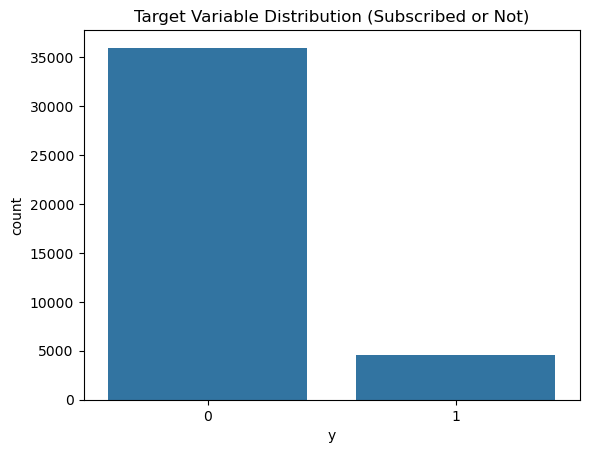

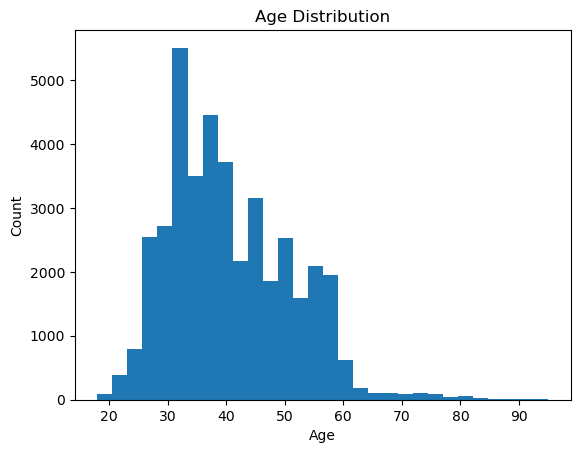

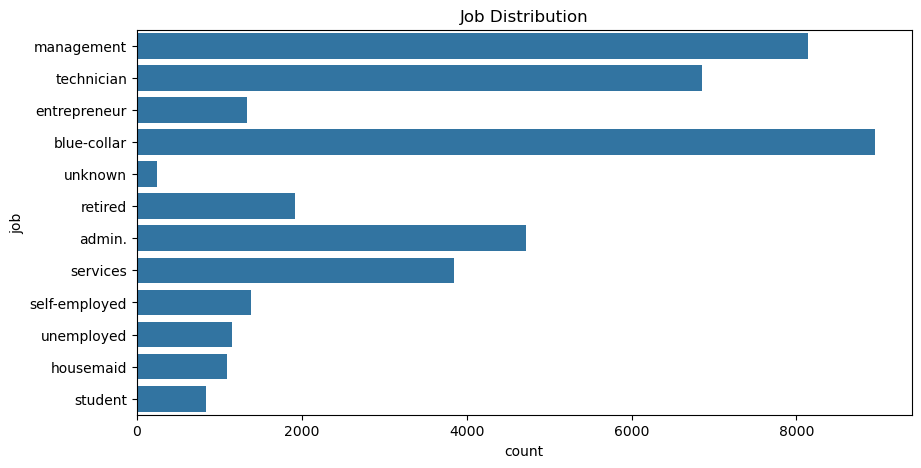

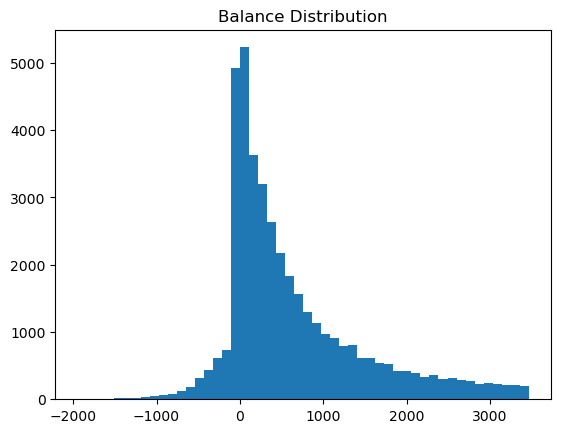

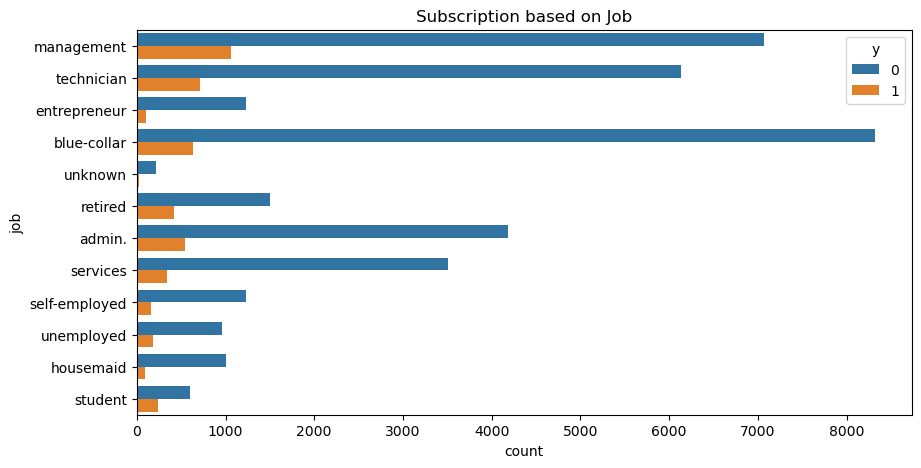

In [16]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution (Subscribed or Not)")
plt.show() #get an idea if Data is imbalanced


plt.hist(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(y='job', data=df)
plt.title("Job Distribution")
plt.show()

plt.hist(df['balance'], bins=50)
plt.title("Balance Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(y='job', hue='y', data=df)
plt.title("Subscription based on Job")
plt.show()


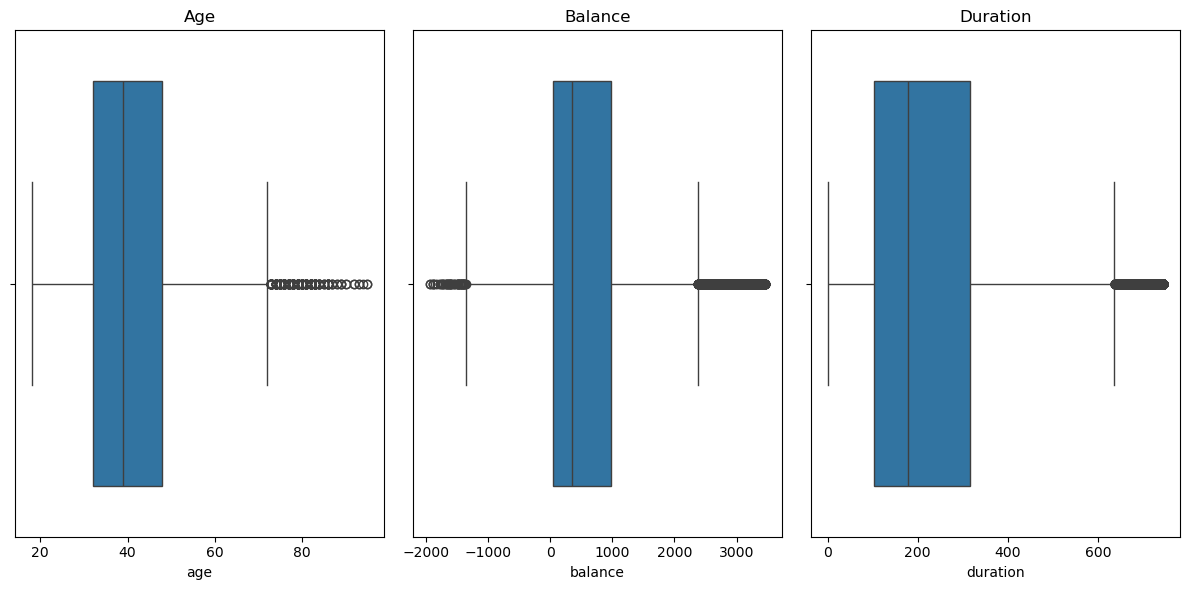

In [17]:
#Display Outliers
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
sns.boxplot(x=df['age'])
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(x=df['balance'])
plt.title("Balance")

plt.subplot(1,3,3)
sns.boxplot(x=df['duration'])
plt.title("Duration")

plt.tight_layout()
plt.show()



In [18]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['balance'] >= lower) & (df['balance'] <= upper)]

print("After removing balance outliers:", df.shape)

After removing balance outliers: (37934, 17)


In [ ]:
#Clipping duretion variable
upper_limit = df['duration'].quantile(0.95)


df['duration'] = df['duration'].clip(upper=upper_limit)


print("Max duration after clipping:", df['duration'].max())

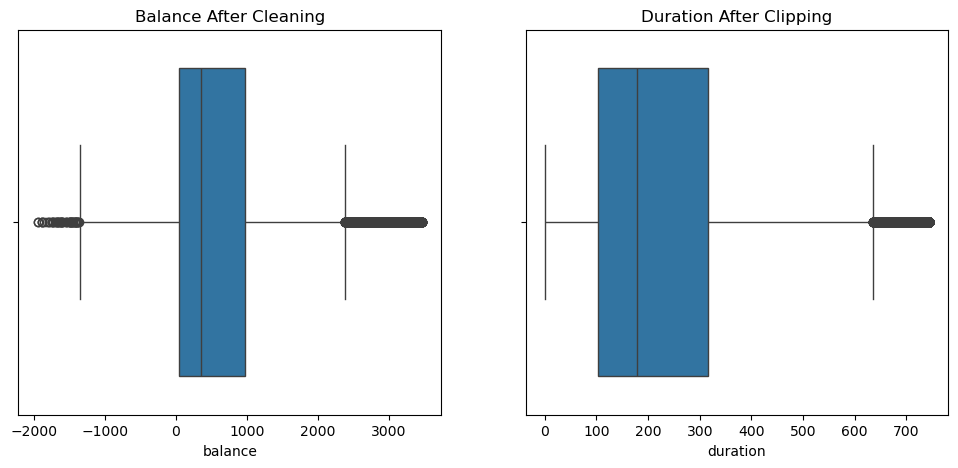

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['balance'])
plt.title("Balance After Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df['duration'])
plt.title("Duration After Clipping")

plt.show()

In [20]:
# Convert target first
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Then encode features
df_encoded = pd.get_dummies(df, drop_first=True)

In [15]:
 # Save preprocessed data to a new CSV file
df_encoded.to_csv('preprocessed_data.csv', index=False)

print("Preprocessing completed ✅")

Preprocessing completed ✅
